# Non-ML Baselines

Five credible heuristic baselines so the benefit of ML is clearly quantifiable:

| Baseline | Description |
|----------|-------------|
| **Naïve** | Predict next week = this week's sales per article |
| **MA-4** | Rolling 4-week mean per article |
| **Seasonal MA** | Average of MA-4 and same-week-last-year (per article) |
| **Croston** | Separate exponential smoothing for demand size and inter-demand interval — designed for intermittent demand |
| **Brown's SES** | Simple exponential smoothing (single level) — standard univariate benchmark |
| **Holt's method** | Double exponential smoothing (level + trend) — extends Brown with a trend component |

Metrics reported: **RMSE**, **MAE**, **Non-zero MAPE** (MAPE on weeks with actual sales > 0 only — using all weeks inflates MAPE to millions of % because of zero denominator).

All baselines use **only information available before the prediction week** (no leakage).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
os.makedirs('plots/baselines', exist_ok=True)

BASE      = '/Users/kamilaya/Desktop/thesis'
TRAIN_END = '2019-04-30'
VAL_END   = '2019-12-31'

In [2]:
# ── Load unscaled preprocessed data ─────────────────────────────────────────
df = pd.read_csv(f'{BASE}/tshirts_preprocessed.csv', parse_dates=['week_start'])
df = df.sort_values(['article_id', 'week_start']).reset_index(drop=True)

train_df = df[df['week_start'] <= TRAIN_END].copy()
val_df   = df[(df['week_start'] > TRAIN_END) & (df['week_start'] <= VAL_END)].copy()
test_df  = df[df['week_start'] > VAL_END].copy()

print(f'Full grid: {df.shape}')
print(f'Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')
print(f'Zero-sale weeks (train): {(train_df["weekly_sales_volume"] == 0).mean()*100:.1f}%')

Full grid: (834538, 113)
Train: 259,809  |  Val: 275,555  |  Test: 299,174
Zero-sale weeks (train): 78.4%


In [3]:
# ── Metric helpers ────────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))

def nz_mape(y_true, y_pred):
    """MAPE computed only on weeks with actual sales > 0.
    Using all weeks (including 82% zeros) gives undefined/infinite values.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def score(label, y_true, y_pred, split):
    y_pred_clipped = np.clip(y_pred, 0, None)  # sales can't be negative
    return {
        'model':        label,
        'split':        split,
        'RMSE':         round(rmse(y_true, y_pred_clipped), 4),
        'MAE':          round(mae(y_true, y_pred_clipped),  4),
        'NZ-MAPE (%)':  round(nz_mape(y_true, y_pred_clipped), 2),
    }

all_results = []

---
## Baseline 1: Naïve (Last Week)

**Prediction rule:** `ŷ(t) = y(t-1)`  
The simplest possible baseline — predict each article's sales as equal to last week's value.  
Already encoded as `sales_lag1` in the preprocessed dataset (unscaled).

In [4]:
naive_val_pred  = val_df['sales_lag1'].values
naive_test_pred = test_df['sales_lag1'].values

all_results.append(score('Naïve (last week)', val_df['weekly_sales_volume'],  naive_val_pred,  'val'))
all_results.append(score('Naïve (last week)', test_df['weekly_sales_volume'], naive_test_pred, 'test'))

print('Naïve baseline')
print(f"  Val  RMSE={all_results[-2]['RMSE']:.4f}  MAE={all_results[-2]['MAE']:.4f}  NZ-MAPE={all_results[-2]['NZ-MAPE (%)']:.1f}%")
print(f"  Test RMSE={all_results[-1]['RMSE']:.4f}  MAE={all_results[-1]['MAE']:.4f}  NZ-MAPE={all_results[-1]['NZ-MAPE (%)']:.1f}%")

Naïve baseline
  Val  RMSE=5.6068  MAE=1.1274  NZ-MAPE=80.1%
  Test RMSE=6.6678  MAE=1.1819  NZ-MAPE=86.9%


---
## Baseline 2: Seasonal Moving Average

Two components combined:
- **MA-4:** Mean of the previous 4 weeks per article (already in `sales_rolling4_mean`)
- **SWLY (Same Week Last Year):** Look up the same ISO week from 12 months prior

Final prediction = mean of MA-4 and SWLY (SWLY missing → fall back to article training mean).

In [5]:
# MA-4: already available as unscaled sales_rolling4_mean
ma4_val_pred  = val_df['sales_rolling4_mean'].values
ma4_test_pred = test_df['sales_rolling4_mean'].values

all_results.append(score('MA-4 (rolling 4w)', val_df['weekly_sales_volume'],  ma4_val_pred,  'val'))
all_results.append(score('MA-4 (rolling 4w)', test_df['weekly_sales_volume'], ma4_test_pred, 'test'))

print('MA-4 sub-baseline')
print(f"  Val  RMSE={all_results[-2]['RMSE']:.4f}")
print(f"  Test RMSE={all_results[-1]['RMSE']:.4f}")

MA-4 sub-baseline
  Val  RMSE=6.5538
  Test RMSE=7.8034


In [6]:
# Same-Week-Last-Year (SWLY) ─────────────────────────────────────────────────
# Build lookup: article_id + ISO week_of_year + year → mean weekly sales
# Available history up to the prediction horizon:
#   val predictions (2019) → look up 2018 from train
#   test predictions (2020) → look up 2019 from train + val

history = df[df['week_start'] <= VAL_END][['article_id', 'week_of_year', 'year', 'weekly_sales_volume']].copy()

# Aggregate to article + year + week_of_year (handles any duplicates)
swly_lookup = (
    history
    .groupby(['article_id', 'year', 'week_of_year'])['weekly_sales_volume']
    .mean()
    .reset_index()
    .rename(columns={'year': 'lookup_year', 'weekly_sales_volume': 'swly_sales'})
)

# Article-level fallback (mean over entire training period)
article_train_mean = (
    train_df.groupby('article_id')['weekly_sales_volume']
    .mean()
    .rename('article_mean')
    .reset_index()
)

def add_swly(pred_df, available_years_up_to):
    """
    For each row in pred_df, look up (article_id, year-1, week_of_year).
    Falls back to article training mean if SWLY is unavailable.
    """
    lookup_slice = swly_lookup[swly_lookup['lookup_year'] <= available_years_up_to]
    merged = pred_df[['article_id', 'week_of_year', 'year']].copy()
    merged['lookup_year'] = merged['year'] - 1
    merged = merged.merge(lookup_slice, on=['article_id', 'week_of_year', 'lookup_year'], how='left')
    merged = merged.merge(article_train_mean, on='article_id', how='left')
    # Fill missing SWLY with article mean
    swly = merged['swly_sales'].fillna(merged['article_mean']).fillna(0).values
    n_filled = merged['swly_sales'].isna().sum()
    print(f"    SWLY: {len(merged) - n_filled:,} matched, {n_filled:,} filled with article mean")
    return swly

print('Building SWLY for val set (looking up 2018):')
swly_val  = add_swly(val_df,  available_years_up_to=2018)
print('Building SWLY for test set (looking up 2019):')
swly_test = add_swly(test_df, available_years_up_to=2019)

Building SWLY for val set (looking up 2018):
    SWLY: 125,968 matched, 149,587 filled with article mean
Building SWLY for test set (looking up 2019):
    SWLY: 299,174 matched, 0 filled with article mean


In [7]:
# Seasonal MA = mean(MA-4, SWLY)
sma_val_pred  = (ma4_val_pred  + swly_val)  / 2
sma_test_pred = (ma4_test_pred + swly_test) / 2

all_results.append(score('Seasonal MA (MA-4 + SWLY)', val_df['weekly_sales_volume'],  sma_val_pred,  'val'))
all_results.append(score('Seasonal MA (MA-4 + SWLY)', test_df['weekly_sales_volume'], sma_test_pred, 'test'))

print('Seasonal MA (MA-4 + SWLY)')
print(f"  Val  RMSE={all_results[-2]['RMSE']:.4f}  MAE={all_results[-2]['MAE']:.4f}  NZ-MAPE={all_results[-2]['NZ-MAPE (%)']:.1f}%")
print(f"  Test RMSE={all_results[-1]['RMSE']:.4f}  MAE={all_results[-1]['MAE']:.4f}  NZ-MAPE={all_results[-1]['NZ-MAPE (%)']:.1f}%")

Seasonal MA (MA-4 + SWLY)
  Val  RMSE=8.0645  MAE=2.0613  NZ-MAPE=113.9%
  Test RMSE=10.6762  MAE=2.7740  NZ-MAPE=170.7%


---
## Baseline 3: Croston's Method

Standard method for **intermittent demand forecasting** (Croston, 1972).  
Maintains two separate exponential smoothing estimates:
- **z** = smoothed demand size (updated only when demand > 0)
- **p** = smoothed inter-demand interval (weeks between non-zero observations)

**Forecast = z / p** (constant until the next update).

Fitted per article on training data; α = β = 0.1 (standard default for stable fashion demand).

In [8]:
def croston_fit(series, alpha=0.1, beta=0.1):
    """
    Fit Croston's method on a 1-D array of weekly sales.
    Returns (z, p): smoothed demand size and inter-demand interval.
    """
    series = np.asarray(series, dtype=float)
    nonzero_idx = np.where(series > 0)[0]

    if len(nonzero_idx) == 0:
        return 0.0, 1.0   # never sold → forecast 0

    # Initialise at first non-zero observation
    z = series[nonzero_idx[0]]
    p = float(nonzero_idx[0] + 1)  # periods to first demand (including t=0)

    # Update through subsequent non-zero observations
    for k in range(1, len(nonzero_idx)):
        interval = nonzero_idx[k] - nonzero_idx[k - 1]  # weeks between demands
        z = alpha * series[nonzero_idx[k]] + (1 - alpha) * z
        p = beta  * interval                + (1 - beta)  * p

    return z, p


def build_croston_forecasts(train_series_df, pred_df, alpha=0.1, beta=0.1):
    """
    Fit Croston per article on train_series_df, then return
    a forecast array aligned to pred_df index.
    """
    forecasts_by_article = {}
    for art_id, grp in train_series_df.groupby('article_id'):
        series = grp.sort_values('week_start')['weekly_sales_volume'].values
        z, p   = croston_fit(series, alpha=alpha, beta=beta)
        forecasts_by_article[art_id] = z / p if p > 0 else 0.0

    # Global fallback (unseen articles → overall training mean)
    global_mean = train_series_df['weekly_sales_volume'].mean()

    preds = pred_df['article_id'].map(forecasts_by_article).fillna(global_mean).values
    return np.clip(preds, 0, None)

In [9]:
# Fit Croston on train only → forecast val
print('Fitting Croston per article on training data...')
croston_val_pred = build_croston_forecasts(train_df, val_df)

# Fit Croston on train+val → forecast test
print('Fitting Croston per article on train + val data...')
train_val_df     = df[df['week_start'] <= VAL_END].copy()
croston_test_pred = build_croston_forecasts(train_val_df, test_df)

all_results.append(score("Croston's method", val_df['weekly_sales_volume'],  croston_val_pred,  'val'))
all_results.append(score("Croston's method", test_df['weekly_sales_volume'], croston_test_pred, 'test'))

print()
print("Croston's method")
print(f"  Val  RMSE={all_results[-2]['RMSE']:.4f}  MAE={all_results[-2]['MAE']:.4f}  NZ-MAPE={all_results[-2]['NZ-MAPE (%)']:.1f}%")
print(f"  Test RMSE={all_results[-1]['RMSE']:.4f}  MAE={all_results[-1]['MAE']:.4f}  NZ-MAPE={all_results[-1]['NZ-MAPE (%)']:.1f}%")

Fitting Croston per article on training data...
Fitting Croston per article on train + val data...

Croston's method
  Val  RMSE=12.0238  MAE=3.2299  NZ-MAPE=156.0%
  Test RMSE=12.6561  MAE=3.3645  NZ-MAPE=136.2%


---
## Baseline 4: Brown's Simple Exponential Smoothing (SES)

**Brown's method** (single/simple exponential smoothing) maintains a single smoothed level:

$$\hat{y}_{t+1} = \alpha y_t + (1-\alpha)\hat{y}_t$$

- α = 0.1 (consistent with Croston's α)
- Fitted per article on training data; constant forecast for all future periods
- Serves as the standard univariate benchmark; ignores trend and seasonality

Added at pre-defense committee's suggestion as a stronger exponential-smoothing baseline.

In [ ]:
def brown_fit(series, alpha=0.1):
    """
    Brown's Simple Exponential Smoothing.
    Returns the final smoothed level used as a constant forecast.
    """
    s = np.asarray(series, dtype=float)
    if len(s) == 0:
        return 0.0
    level = s[0]
    for y in s[1:]:
        level = alpha * y + (1 - alpha) * level
    return level


def build_brown_forecasts(train_series_df, pred_df, alpha=0.1):
    """
    Fit Brown's SES per article on train_series_df,
    then return a constant forecast array aligned to pred_df.
    """
    forecasts = {}
    for art_id, grp in train_series_df.groupby('article_id'):
        series = grp.sort_values('week_start')['weekly_sales_volume'].values
        forecasts[art_id] = brown_fit(series, alpha=alpha)

    global_mean = train_series_df['weekly_sales_volume'].mean()
    preds = pred_df['article_id'].map(forecasts).fillna(global_mean).values
    return np.clip(preds, 0, None)


print('Fitting Brown SES per article on training data...')
brown_val_pred  = build_brown_forecasts(train_df,    val_df)
print('Fitting Brown SES per article on train + val data...')
brown_test_pred = build_brown_forecasts(train_val_df, test_df)

all_results.append(score("Brown's SES", val_df['weekly_sales_volume'],  brown_val_pred,  'val'))
all_results.append(score("Brown's SES", test_df['weekly_sales_volume'], brown_test_pred, 'test'))

print()
print("Brown's SES")
print(f"  Val  RMSE={all_results[-2]['RMSE']:.4f}  MAE={all_results[-2]['MAE']:.4f}  NZ-MAPE={all_results[-2]['NZ-MAPE (%)']:.1f}%")
print(f"  Test RMSE={all_results[-1]['RMSE']:.4f}  MAE={all_results[-1]['MAE']:.4f}  NZ-MAPE={all_results[-1]['NZ-MAPE (%)']:.1f}%")

---
## Baseline 5: Holt's Double Exponential Smoothing

**Holt's method** extends Brown's SES with a separate trend component:

$$\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)b_{t-1}$$
$$\hat{y}_{t+h} = \ell_t + h \cdot b_t$$

- α = 0.1, β = 0.05 (small β dampens trend on sparse intermittent data)
- Fitted per article on training data
- Forecast at horizon h = weeks since training end; h-step-ahead is appropriate here
  because the constant-forecast assumption of Naïve/Croston/Brown understates
  growth trends present in some article trajectories

Added at pre-defense committee's suggestion.

In [ ]:
def holt_fit(series, alpha=0.1, beta=0.05):
    """
    Holt's Double Exponential Smoothing (level + trend).
    Small beta (0.05) dampens trend for sparse intermittent demand series.
    Returns (level, trend) used to forecast ŷ_{t+h} = level + h * trend.
    """
    s = np.asarray(series, dtype=float)
    if len(s) == 0:
        return 0.0, 0.0
    if len(s) == 1:
        return float(s[0]), 0.0
    level = float(s[0])
    trend = float(s[1] - s[0])
    for y in s[1:]:
        prev_level = level
        level = alpha * y + (1 - alpha) * (prev_level + trend)
        trend = beta  * (level - prev_level) + (1 - beta) * trend
    return level, trend


def build_holt_forecasts(train_series_df, pred_df, alpha=0.1, beta=0.05):
    """
    Fit Holt's method per article on train_series_df.
    Forecast at horizon h = weeks since training end (h >= 1).
    """
    level_map, trend_map = {}, {}
    for art_id, grp in train_series_df.groupby('article_id'):
        series = grp.sort_values('week_start')['weekly_sales_volume'].values
        l, t   = holt_fit(series, alpha=alpha, beta=beta)
        level_map[art_id] = l
        trend_map[art_id] = t

    global_mean = train_series_df['weekly_sales_volume'].mean()
    train_end   = train_series_df['week_start'].max()

    level_s  = pd.Series(level_map)
    trend_s  = pd.Series(trend_map)
    levels   = pred_df['article_id'].map(level_s).fillna(global_mean).values
    trends   = pred_df['article_id'].map(trend_s).fillna(0.0).values
    horizons = np.maximum(1, (pred_df['week_start'] - train_end).dt.days // 7).values

    return np.clip(levels + trends * horizons, 0, None)


print('Fitting Holt method per article on training data...')
holt_val_pred  = build_holt_forecasts(train_df,    val_df)
print('Fitting Holt method per article on train + val data...')
holt_test_pred = build_holt_forecasts(train_val_df, test_df)

all_results.append(score("Holt's method", val_df['weekly_sales_volume'],  holt_val_pred,  'val'))
all_results.append(score("Holt's method", test_df['weekly_sales_volume'], holt_test_pred, 'test'))

print()
print("Holt's method")
print(f"  Val  RMSE={all_results[-2]['RMSE']:.4f}  MAE={all_results[-2]['MAE']:.4f}  NZ-MAPE={all_results[-2]['NZ-MAPE (%)']:.1f}%")
print(f"  Test RMSE={all_results[-1]['RMSE']:.4f}  MAE={all_results[-1]['MAE']:.4f}  NZ-MAPE={all_results[-1]['NZ-MAPE (%)']:.1f}%")

---
## Comparison: Baselines vs. ML Models

ML MAPE values from `model_results.csv` are meaningless (≈ 3 million %) due to zero-denominator issues at article level. We recompute NZ-MAPE (non-zero weeks only) consistently for all methods.

In [10]:
# ── Re-compute NZ-MAPE for ML models from saved predictions ──────────────────
import joblib

val_scaled  = pd.read_csv(f'{BASE}/tshirts_val.csv',  parse_dates=['week_start'])
test_scaled = pd.read_csv(f'{BASE}/tshirts_test.csv', parse_dates=['week_start'])

# LightGBM silently converts OHE column names: spaces → underscores internally.
# XGBoost and RandomForest keep the original names (with spaces).
# We prepare both variants and let each model choose the one it matches.
_OHE_PREFIXES = ('index_group_name_', 'colour_group_name_',
                 'graphical_appearance_name_', 'perceived_colour_value_name_')

def _normalise_cols(df):
    """Return a copy with spaces replaced by underscores in OHE column names."""
    return df.rename(columns={
        c: c.replace(' ', '_')
        for c in df.columns if any(c.startswith(p) for p in _OHE_PREFIXES)
    })

# Two variants: original column names (XGBoost / RF) and normalised (LightGBM)
val_orig  = val_scaled
test_orig = test_scaled
val_norm  = _normalise_cols(val_scaled)
test_norm = _normalise_cols(test_scaled)

TARGET = 'log_sales_volume'
y_val_true  = np.expm1(val_scaled[TARGET].values)
y_test_true = np.expm1(test_scaled[TARGET].values)

def _best_X(model, val_or_test_orig, val_or_test_norm):
    """
    Return (X, feats) using whichever column-name format the model expects.
    Detects the right format by counting how many model feature names are
    found in the original vs. the normalised DataFrame.
    """
    if hasattr(model, 'feature_name_'):        # LightGBM attribute (underscored)
        model_feats = list(model.feature_name_)
    elif hasattr(model, 'feature_names_in_'):  # sklearn / XGBoost (original)
        model_feats = [str(f) for f in model.feature_names_in_]
    else:
        raise AttributeError('Model has no recognisable feature-name attribute.')

    orig_hits = sum(f in val_or_test_orig.columns for f in model_feats)
    norm_hits = sum(f in val_or_test_norm.columns for f in model_feats)
    df = val_or_test_norm if norm_hits > orig_hits else val_or_test_orig

    feats = [f for f in model_feats if f in df.columns]
    return df[feats], feats

model_files = {
    'LightGBM (baseline)':     'LightGBM_Baselin.pkl',
    'XGBoost (baseline)':      'XGBoost_Baselin.pkl',
    'RandomForest (baseline)': 'RandomForest_Baselin.pkl',
    'LightGBM (macro)':        'LightGBM_Macro-e.pkl',
    'XGBoost (macro)':         'XGBoost_Macro-e.pkl',
    'RandomForest (macro)':    'RandomForest_Macro-e.pkl',
}

ml_results = []

for label, fname in model_files.items():
    fpath = f'{BASE}/saved_models/{fname}'
    if not os.path.exists(fpath):
        print(f'  [SKIP] {label} — model file not found: {fname}')
        continue

    model = joblib.load(fpath)

    X_val,  _ = _best_X(model, val_orig,  val_norm)
    X_test, _ = _best_X(model, test_orig, test_norm)

    for split_name, X, y_true in [
        ('val',  X_val,  y_val_true),
        ('test', X_test, y_test_true),
    ]:
        pred_log = np.clip(model.predict(X), 0, None)
        ml_results.append(score(label, y_true, np.expm1(pred_log), split_name))

print(f'Collected ML results for {len(ml_results)//2} models × 2 splits')


Collected ML results for 6 models × 2 splits


In [11]:
# ── Full comparison table ─────────────────────────────────────────────────────
comparison = pd.DataFrame(all_results + ml_results)

# Separate val and test for display
for split in ['val', 'test']:
    sub = comparison[comparison['split'] == split].copy()
    sub = sub.sort_values('RMSE').reset_index(drop=True)
    sub.index = sub.index + 1
    print(f'\n{"="*68}')
    print(f'  {split.upper()} SET RESULTS  (lower RMSE / MAE / NZ-MAPE is better)')
    print(f'{"="*68}')
    print(sub[['model', 'RMSE', 'MAE', 'NZ-MAPE (%)']].to_string())

comparison.to_csv(f'{BASE}/baseline_results.csv', index=False)
print('\nSaved: baseline_results.csv')


  VAL SET RESULTS  (lower RMSE / MAE / NZ-MAPE is better)
                        model     RMSE     MAE  NZ-MAPE (%)
1         LightGBM (baseline)   5.2051  0.9669        59.69
2     RandomForest (baseline)   5.2160  0.9941        67.16
3        RandomForest (macro)   5.2179  0.9829        66.93
4            LightGBM (macro)   5.2255  0.9549        57.77
5          XGBoost (baseline)   5.2765  0.9757        59.08
6             XGBoost (macro)   5.3153  0.9762        58.30
7           Naïve (last week)   5.6068  1.1274        80.08
8           MA-4 (rolling 4w)   6.5538  1.3750        90.24
9   Seasonal MA (MA-4 + SWLY)   8.0645  2.0613       113.88
10           Croston's method  12.0238  3.2299       155.97

  TEST SET RESULTS  (lower RMSE / MAE / NZ-MAPE is better)
                        model     RMSE     MAE  NZ-MAPE (%)
1     RandomForest (baseline)   6.2333  1.0911        75.28
2        RandomForest (macro)   6.2418  1.0900        75.14
3         LightGBM (baseline)   6.2436  1

In [12]:
# ── ML improvement over best baseline ────────────────────────────────────────
baseline_labels = ['Naïve (last week)', 'MA-4 (rolling 4w)',
                   'Seasonal MA (MA-4 + SWLY)', "Croston's method",
                   "Brown's SES", "Holt's method"]

test_comp = comparison[comparison['split'] == 'test'].copy()

best_baseline_rmse = test_comp[test_comp['model'].isin(baseline_labels)]['RMSE'].min()
best_ml_rmse       = test_comp[~test_comp['model'].isin(baseline_labels)]['RMSE'].min()
improvement        = (best_baseline_rmse - best_ml_rmse) / best_baseline_rmse * 100

print(f'Best baseline RMSE (test): {best_baseline_rmse:.4f}')
print(f'Best ML RMSE (test):       {best_ml_rmse:.4f}')
print(f'ML improvement over best baseline: {improvement:.1f}%')

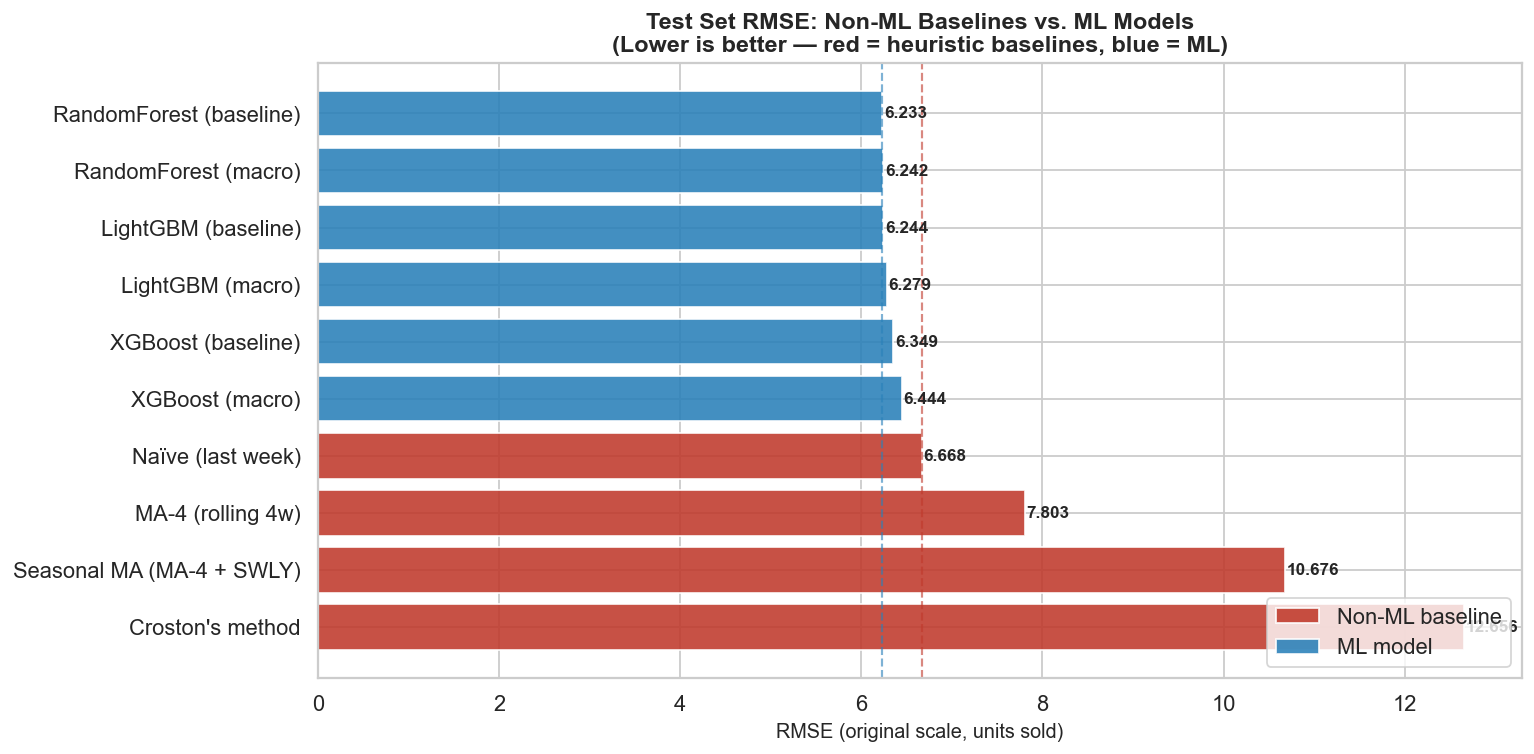

Saved: plots/baselines/B1_rmse_comparison.png


In [13]:
# ── Plot 1: RMSE comparison bar chart (test set) ─────────────────────────────
test_comp_sorted = test_comp.sort_values('RMSE', ascending=False).reset_index(drop=True)

colors = [
    '#c0392b' if m in baseline_labels else '#2980b9'
    for m in test_comp_sorted['model']
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(test_comp_sorted['model'], test_comp_sorted['RMSE'],
               color=colors, edgecolor='white', alpha=0.88)
for bar, v in zip(bars, test_comp_sorted['RMSE']):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9.5, fontweight='bold')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#c0392b', alpha=0.88, label='Non-ML baseline'),
    Patch(facecolor='#2980b9', alpha=0.88, label='ML model'),
]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_xlabel('RMSE (original scale, units sold)', fontsize=11)
ax.set_title('Test Set RMSE: Non-ML Baselines vs. ML Models\n'
             '(Lower is better — red = heuristic baselines, blue = ML)',
             fontsize=13, fontweight='bold')
ax.axvline(best_ml_rmse, color='#2980b9', linestyle='--', linewidth=1.2, alpha=0.6)
ax.axvline(best_baseline_rmse, color='#c0392b', linestyle='--', linewidth=1.2, alpha=0.6)
plt.tight_layout()
plt.savefig('plots/baselines/B1_rmse_comparison.png')
plt.show()
print('Saved: plots/baselines/B1_rmse_comparison.png')

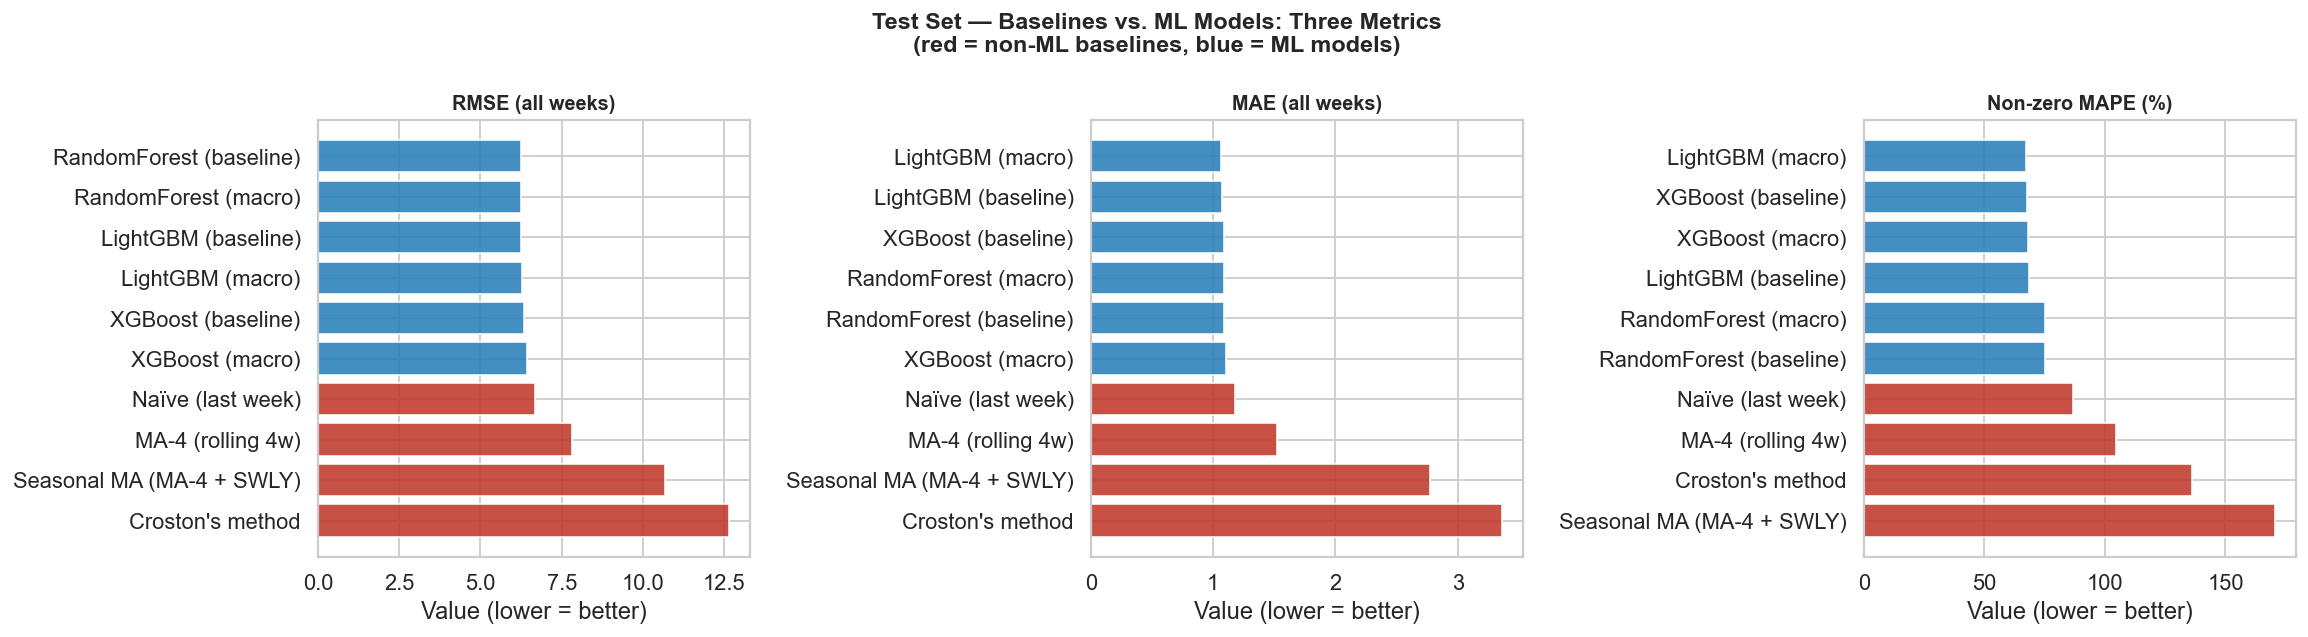

Saved: plots/baselines/B2_three_metrics.png


In [14]:
# ── Plot 2: Three-metric comparison (RMSE, MAE, NZ-MAPE) ─────────────────────
metrics = ['RMSE', 'MAE', 'NZ-MAPE (%)']
metric_labels = ['RMSE (all weeks)', 'MAE (all weeks)', 'Non-zero MAPE (%)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, mlabel in zip(axes, metrics, metric_labels):
    sub = test_comp.sort_values(metric, ascending=False).reset_index(drop=True)
    colors_m = [
        '#c0392b' if m in baseline_labels else '#2980b9'
        for m in sub['model']
    ]
    ax.barh(sub['model'], sub[metric], color=colors_m, edgecolor='white', alpha=0.88)
    ax.set_title(mlabel, fontweight='bold', fontsize=11)
    ax.set_xlabel('Value (lower = better)')

plt.suptitle('Test Set — Baselines vs. ML Models: Three Metrics\n'
             '(red = non-ML baselines, blue = ML models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/baselines/B2_three_metrics.png')
plt.show()
print('Saved: plots/baselines/B2_three_metrics.png')

In [15]:
# ── Plot 3: Weekly aggregate — actual vs. best baseline vs. best ML ───────────
best_ml_label = test_comp[~test_comp['model'].isin(baseline_labels)].loc[
    test_comp[~test_comp['model'].isin(baseline_labels)]['RMSE'].idxmin(), 'model'
]
best_bl_label = test_comp[test_comp['model'].isin(baseline_labels)].loc[
    test_comp[test_comp['model'].isin(baseline_labels)]['RMSE'].idxmin(), 'model'
]

pred_map = {
    'Naïve (last week)':         naive_test_pred,
    'MA-4 (rolling 4w)':         ma4_test_pred,
    'Seasonal MA (MA-4 + SWLY)': sma_test_pred,
    "Croston's method":          croston_test_pred,
    "Brown's SES":               brown_test_pred,
    "Holt's method":             holt_test_pred,
}

test_plot = test_df[['week_start', 'weekly_sales_volume']].copy()
test_plot['best_baseline_pred'] = np.clip(pred_map[best_bl_label], 0, None)

weekly = test_plot.groupby('week_start').agg(
    actual=('weekly_sales_volume', 'sum'),
    best_baseline=('best_baseline_pred', 'sum')
).reset_index()

# model_files is {label: filename} — look up directly, no tuple unpacking
best_ml_fname = model_files[best_ml_label]
best_ml_path  = f'{BASE}/saved_models/{best_ml_fname}'

if os.path.exists(best_ml_path):
    best_model = joblib.load(best_ml_path)
    X_test_best, _ = _best_X(best_model, test_orig, test_norm)
    ml_pred_raw = np.expm1(np.clip(best_model.predict(X_test_best), 0, None))

    test_ml_copy = test_orig[['week_start']].copy()
    test_ml_copy['ml_pred'] = ml_pred_raw
    weekly = weekly.merge(
        test_ml_copy.groupby('week_start')['ml_pred'].sum().reset_index(),
        on='week_start', how='left'
    )

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(weekly['week_start'], weekly['actual'],
            label='Actual', color='black', linewidth=2)
    ax.plot(weekly['week_start'], weekly['best_baseline'],
            label=f'Best baseline ({best_bl_label})', color='#c0392b',
            linewidth=1.8, linestyle='--')
    ax.plot(weekly['week_start'], weekly['ml_pred'],
            label=f'Best ML ({best_ml_label})', color='#2980b9',
            linewidth=1.8, linestyle=':')
    ax.axvline(pd.Timestamp('2020-03-01'), color='grey', linestyle='--',
               linewidth=1, label='COVID-19 (Mar 2020)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.xticks(rotation=30)
    ax.set_title('Test Set: Actual vs. Best Baseline vs. Best ML — Weekly Aggregate',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Total Weekly Sales')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots/baselines/B3_actual_vs_best_comparison.png')
    plt.show()
    print('Saved: plots/baselines/B3_actual_vs_best_comparison.png')
else:
    print(f'Best ML model not found — skipping plot ({best_ml_path})')


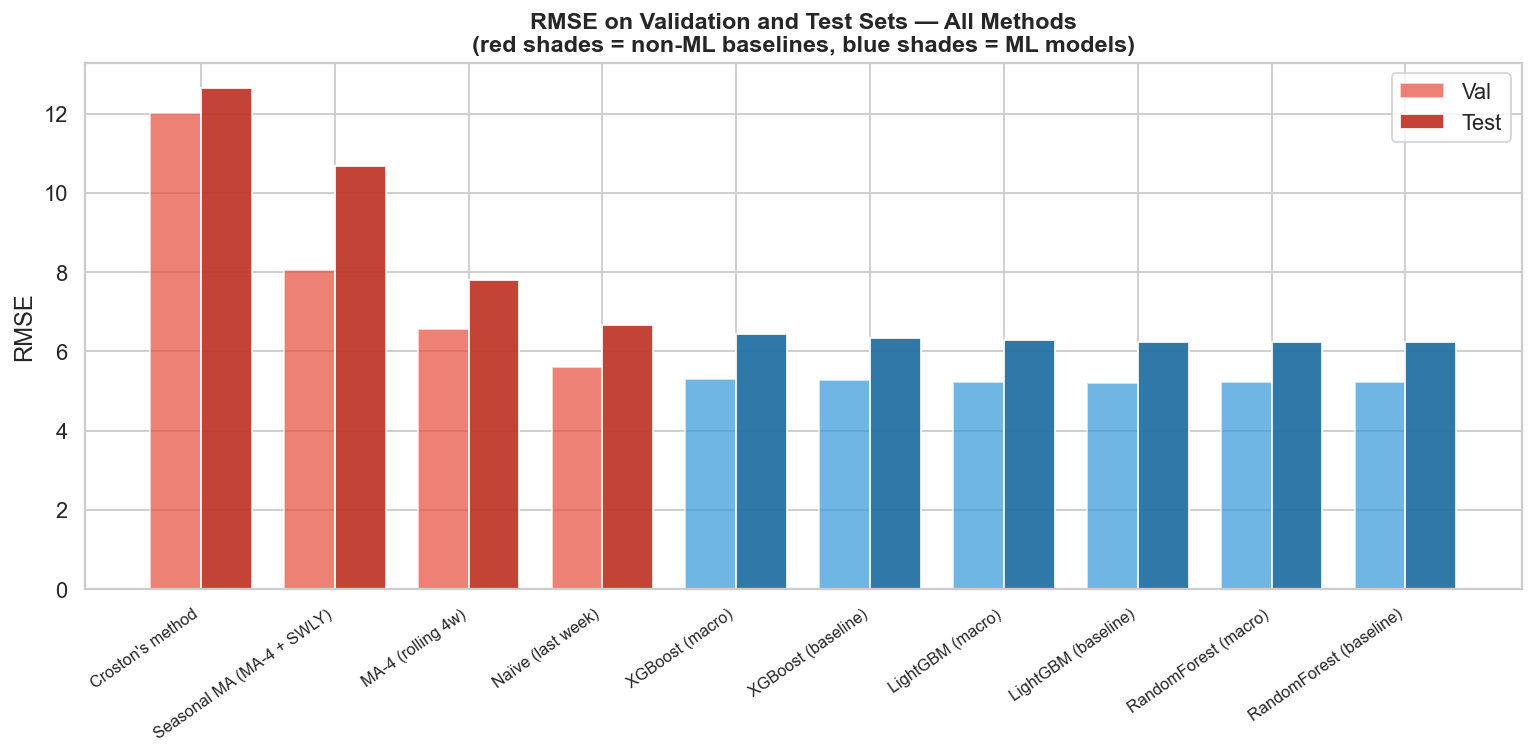

Saved: plots/baselines/B4_val_vs_test_rmse.png


In [16]:
# ── Plot 4: Val vs. Test RMSE side-by-side (stability check) ─────────────────
pivot = comparison.pivot_table(index='model', columns='split', values='RMSE')
pivot = pivot.sort_values('test', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pivot))
width = 0.38
c_val  = ['#e74c3c' if m in baseline_labels else '#3498db' for m in pivot.index]
c_test = ['#c0392b' if m in baseline_labels else '#2471a3' for m in pivot.index]

bars1 = ax.bar(x - width/2, pivot['val'],  width, label='Val',  color=c_val,  alpha=0.7, edgecolor='white')
bars2 = ax.bar(x + width/2, pivot['test'], width, label='Test', color=c_test, alpha=0.95, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('RMSE on Validation and Test Sets — All Methods\n'
             '(red shades = non-ML baselines, blue shades = ML models)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/baselines/B4_val_vs_test_rmse.png')
plt.show()
print('Saved: plots/baselines/B4_val_vs_test_rmse.png')

In [17]:
# ── Final summary ─────────────────────────────────────────────────────────────
test_final = comparison[comparison['split'] == 'test'].sort_values('RMSE').reset_index(drop=True)
test_final.index += 1

print('=' * 72)
print('  FINAL RANKING — TEST SET')
print('=' * 72)
print(test_final[['model', 'RMSE', 'MAE', 'NZ-MAPE (%)']].to_string())
print()
print(f'Best non-ML baseline RMSE : {best_baseline_rmse:.4f}  ({best_bl_label})')
print(f'Best ML model RMSE        : {best_ml_rmse:.4f}  ({best_ml_label})')
print(f'ML improvement            : {improvement:.1f}%')
print()
print('NZ-MAPE note: computed only on weeks with actual sales > 0 to avoid')
print('the zero-denominator problem that inflates MAPE to millions of % when')
print('using all article-weeks (81.8% of which have zero sales).')
print()
print('Plots saved to: plots/baselines/')
print('  B1_rmse_comparison.png          — test RMSE bar chart')
print('  B2_three_metrics.png            — RMSE / MAE / NZ-MAPE panels')
print('  B3_actual_vs_best_comparison.png — weekly actual vs best baseline vs best ML')
print('  B4_val_vs_test_rmse.png         — val vs test RMSE stability')

  FINAL RANKING — TEST SET
                        model     RMSE     MAE  NZ-MAPE (%)
1     RandomForest (baseline)   6.2333  1.0911        75.28
2        RandomForest (macro)   6.2418  1.0900        75.14
3         LightGBM (baseline)   6.2436  1.0702        68.55
4            LightGBM (macro)   6.2789  1.0668        67.33
5          XGBoost (baseline)   6.3489  1.0879        67.91
6             XGBoost (macro)   6.4445  1.1068        68.13
7           Naïve (last week)   6.6678  1.1819        86.89
8           MA-4 (rolling 4w)   7.8034  1.5231       104.44
9   Seasonal MA (MA-4 + SWLY)  10.6762  2.7740       170.67
10           Croston's method  12.6561  3.3645       136.15

Best non-ML baseline RMSE : 6.6678  (Naïve (last week))
Best ML model RMSE        : 6.2333  (RandomForest (baseline))
ML improvement            : 6.5%

NZ-MAPE note: computed only on weeks with actual sales > 0 to avoid
the zero-denominator problem that inflates MAPE to millions of % when
using all article-week

---
## Results Comparison Table

Central evidence table for the **Results chapter**.
All metrics on the held-out **test set** (Jan–Sep 2020).
Relative improvement (Δ) is computed against the best non-ML baseline (Naïve).
NZ-MAPE is restricted to weeks with actual sales > 0 to avoid the zero-denominator problem.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# RESULTS COMPARISON TABLE  —  central evidence for the Results chapter
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# ── 1. Build the table dataframe ─────────────────────────────────────────────
test_tbl = comparison[comparison['split'] == 'test'].copy()

baseline_labels = ['Naïve (last week)', 'MA-4 (rolling 4w)',
                   'Seasonal MA (MA-4 + SWLY)', "Croston's method",
                   "Brown's SES", "Holt's method"]

test_tbl['Type'] = test_tbl['model'].apply(
    lambda m: 'Non-ML baseline' if m in baseline_labels else 'ML model'
)

# Best non-ML baseline values (reference row for Δ columns)
ref = test_tbl[test_tbl['Type'] == 'Non-ML baseline']
ref_rmse  = ref['RMSE'].min()
ref_mae   = ref['MAE'].min()
ref_mape  = ref['NZ-MAPE (%)'].min()
ref_label = ref.loc[ref['RMSE'].idxmin(), 'model']

def fmt_delta(val, ref_val):
    pct = (val - ref_val) / ref_val * 100
    sign = '+' if pct > 0 else ''
    return f'{sign}{pct:.1f}%'

test_tbl['Δ RMSE vs best baseline']     = test_tbl['RMSE'].apply(lambda v: fmt_delta(v, ref_rmse))
test_tbl['Δ MAE vs best baseline']      = test_tbl['MAE'].apply(lambda v: fmt_delta(v, ref_mae))
test_tbl['Δ NZ-MAPE vs best baseline']  = test_tbl['NZ-MAPE (%)'].apply(lambda v: fmt_delta(v, ref_mape))

# Sort: ML models first (by RMSE), then baselines (by RMSE)
ml_rows  = test_tbl[test_tbl['Type'] == 'ML model'].sort_values('RMSE')
bl_rows  = test_tbl[test_tbl['Type'] == 'Non-ML baseline'].sort_values('RMSE')
tbl = pd.concat([ml_rows, bl_rows]).reset_index(drop=True)
tbl.index = range(1, len(tbl) + 1)

display_cols = ['model', 'Type', 'RMSE', 'MAE', 'NZ-MAPE (%)',
                'Δ RMSE vs best baseline', 'Δ MAE vs best baseline']
tbl_display = tbl[display_cols].rename(columns={'model': 'Method'})

print('=' * 105)
print(f'  TEST SET — Full Comparison Table   (reference for Δ: {ref_label},  RMSE={ref_rmse:.4f})')
print('=' * 105)
print(tbl_display.to_string())
print('=' * 105)
print(f'  NZ-MAPE = non-zero MAPE (computed only on weeks with actual sales > 0)')
print(f'  Δ = relative change vs best non-ML baseline ({ref_label}); negative = improvement')

# ── 2. Save clean CSV ────────────────────────────────────────────────────────
tbl_display.to_csv(f'{BASE}/results_comparison_table.csv')
print(f'\nSaved: results_comparison_table.csv')

# ── 3. Publication-quality PNG table ─────────────────────────────────────────
os.makedirs('plots/baselines', exist_ok=True)

# Columns and values for the visual table
col_headers = ['Method', 'Type', 'RMSE', 'MAE', 'NZ-MAPE\n(%)',
               'Δ RMSE vs\nbest baseline', 'Δ MAE vs\nbest baseline']
col_keys    = ['model', 'Type', 'RMSE', 'MAE', 'NZ-MAPE (%)',
               'Δ RMSE vs best baseline', 'Δ MAE vs best baseline']

rows_data = []
for _, row in tbl.iterrows():
    rows_data.append([str(row[k]) for k in col_keys])

n_rows = len(rows_data)
n_cols = len(col_headers)
n_ml   = len(ml_rows)

fig_h = 0.45 * n_rows + 1.8
fig, ax = plt.subplots(figsize=(16, fig_h))
ax.axis('off')

# Colour scheme
ML_BG   = '#dbeafe'   # light blue  — ML models
BL_BG   = '#fee2e2'   # light red   — baselines
HDR_BG  = '#1e3a5f'   # dark navy   — header
SEP_BG  = '#f0f4f8'   # very light  — separator row
BEST_ML = '#1d4ed8'   # deep blue   — best ML row highlight
BEST_BL = '#b91c1c'   # deep red    — best baseline row highlight

cell_colors = []
text_colors = []
for i, row in enumerate(rows_data):
    is_ml       = i < n_ml
    is_best_ml  = is_ml  and row[2] == str(ml_rows['RMSE'].min())
    is_best_bl  = not is_ml and row[2] == str(bl_rows['RMSE'].min())
    if is_best_ml:
        bg = [BEST_ML] * n_cols
        tc = ['white'] * n_cols
    elif is_best_bl:
        bg = [BEST_BL] * n_cols
        tc = ['white'] * n_cols
    else:
        bg = [ML_BG if is_ml else BL_BG] * n_cols
        tc = ['#1e3a5f' if is_ml else '#7f1d1d'] * n_cols
    cell_colors.append(bg)
    text_colors.append(tc)

tbl_obj = ax.table(
    cellText=rows_data,
    colLabels=col_headers,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
)
tbl_obj.auto_set_font_size(False)
tbl_obj.set_fontsize(9.5)
tbl_obj.scale(1, 1.55)

# Style header row
for j in range(n_cols):
    cell = tbl_obj[0, j]
    cell.set_facecolor(HDR_BG)
    cell.set_text_props(color='white', fontweight='bold', fontsize=9.5)

# Apply per-cell text colours
for i, tc_row in enumerate(text_colors):
    for j, tc in enumerate(tc_row):
        tbl_obj[i + 1, j].set_text_props(color=tc, fontweight='bold'
            if tc in ('white',) else 'normal')

# Column widths
col_widths = [0.22, 0.14, 0.08, 0.08, 0.09, 0.14, 0.13]
for j, w in enumerate(col_widths):
    tbl_obj.auto_set_column_width(j)
    for i in range(n_rows + 1):
        tbl_obj[i, j].set_width(w)

# Draw a visible separator line between ML and baseline sections
for j in range(n_cols):
    tbl_obj[n_ml, j].visible_edges = 'open'
    tbl_obj[n_ml + 1, j].set_edgecolor('#888888')
    tbl_obj[n_ml + 1, j].visible_edges = 'T'

# Legend patches
legend_handles = [
    mpatches.Patch(facecolor=BEST_ML, label=f'Best ML model'),
    mpatches.Patch(facecolor=ML_BG,   edgecolor='#1e3a5f', label='Other ML models'),
    mpatches.Patch(facecolor=BEST_BL, label=f'Best non-ML baseline ({ref_label})'),
    mpatches.Patch(facecolor=BL_BG,   edgecolor='#7f1d1d', label='Other non-ML baselines'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8.5,
          bbox_to_anchor=(1.0, 1.0), framealpha=0.9)

plt.title(
    'Test Set Results: ML Models vs. Non-ML Baselines\n'
    f'Metrics: RMSE & MAE (all weeks, original scale) | NZ-MAPE (non-zero weeks only)\n'
    f'Δ columns = relative change vs best non-ML baseline ({ref_label}, RMSE={ref_rmse:.4f})',
    fontsize=11, fontweight='bold', pad=14, loc='left'
)

plt.tight_layout()
plt.savefig('plots/baselines/T1_results_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/baselines/T1_results_comparison_table.png')
